<a href="https://colab.research.google.com/github/niRmana11/food-classification-deep-learning/blob/feature%2Fmatheesha-resnet50/notebooks/04_resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SE4050 Deep Learning (2026) — ResNet50 Transfer Learning & Fine-Tuning
### Member 2: Matheesha | Model: Deep Residual Network (ResNet50)

This notebook trains, fine-tunes, and evaluates the **ResNet50** architecture on the Food-101 benchmark under strict, fair experimental conditions.

#### Two-Stage Training Protocol:
1. **Phase 1 (Feature Extraction):** Frozen ImageNet backbone, training the custom classification head (`GlobalAveragePooling2D -> BatchNorm -> Dropout(0.3) -> Dense(101)`) with Adam ($lr=0.001$).
2. **Phase 2 (Fine-Tuning):** Unfreezing Stage 5 residual blocks (`conv5_block1_out` onward) with reduced learning rate ($lr=10^{-5}$) to adapt deep representations to fine-grained food textures.

In [1]:
# Cell 1: Environment Setup & Automatic Git Sync
import os
import sys

REPO_NAME = "food-classification-deep-learning"
BRANCH_NAME = "feature/matheesha-resnet50"
REPO_URL = "https://github.com/niRmana11/food-classification-deep-learning.git"

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("[INFO] Running in Google Colab environment.")
    if not os.path.exists(f"/content/{REPO_NAME}"):
        print(f"[INFO] Cloning repository branch {BRANCH_NAME}...")
        !git clone -b {BRANCH_NAME} {REPO_URL}
        %cd /content/{REPO_NAME}
    else:
        %cd /content/{REPO_NAME}
        !git checkout {BRANCH_NAME}
        !git pull origin {BRANCH_NAME}

    if f"/content/{REPO_NAME}" not in sys.path:
        sys.path.insert(0, f"/content/{REPO_NAME}")

    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"[SUCCESS] GPU detected: {gpus[0].name}")
        !nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv
    else:
        print("[WARNING] No GPU detected! Go to: Runtime -> Change runtime type -> T4 GPU")
else:
    print("[INFO] Running in local environment.")

[INFO] Running in Google Colab environment.
/content/food-classification-deep-learning
Already on 'feature/matheesha-resnet50'
Your branch is up to date with 'origin/feature/matheesha-resnet50'.
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 664 bytes | 132.00 KiB/s, done.
From https://github.com/niRmana11/food-classification-deep-learning
 * branch            feature/matheesha-resnet50 -> FETCH_HEAD
   68fd96d..f2ae7f3  feature/matheesha-resnet50 -> origin/feature/matheesha-resnet50
Updating 68fd96d..f2ae7f3
Fast-forward
 src/preprocessing/data_loader.py | 7 +++++++
 1 file changed, 7 insertions(+)
[SUCCESS] GPU detected: /physical_device:GPU:0
name, memory.total [MiB], memory.free [MiB]
Tesla T4, 15360 MiB, 14910 MiB


In [2]:
# Cell 2: Verify & Acquire Food-101 Dataset (~5GB archive)
!python -m src.data.download_food101

[INFO] Food-101 dataset already extracted at: /content/food-classification-deep-learning/data/raw/food-101


In [3]:
# Cell 3: Load Shared Food-101 Data Pipeline (Model Type: resnet50)
import time
import tensorflow as tf
from src.preprocessing.data_loader import get_food101_datasets

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

print("[INFO] Loading Food-101 datasets for ResNet50 (Caffe BGR zero-centering)...")
t0 = time.time()
train_ds, val_ds, test_ds = get_food101_datasets(
    data_dir="data/raw/food-101",
    splits_dir="data/splits",
    model_type="resnet50",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)
print(f"[SUCCESS] Datasets loaded in {time.time() - t0:.2f}s")

[INFO] Loading Food-101 datasets for ResNet50 (Caffe BGR zero-centering)...
[SUCCESS] Datasets loaded in 3.00s


In [4]:
# Cell 4: Instantiate ResNet50 Architecture (Phase 1: Feature Extraction)
from src.models.resnet50 import build_resnet50_model, compile_resnet50_model

model, base_model = build_resnet50_model(
    num_classes=101,
    input_shape=(224, 224, 3),
    dropout_rate=0.3
)

compile_resnet50_model(model, learning_rate=0.001)
model.summary()

Model: "ResNet50_Food101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 101)            │       206,949 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,802,853 (90.80 MB)

 Trainable params: 211,045 (824.39 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [5]:
# Cell 5: Phase 1 Training (Feature Extraction — Frozen Backbone)
import os
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger

os.makedirs("results/resnet50", exist_ok=True)

callbacks_phase1 = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-5, verbose=1),
    CSVLogger("results/resnet50/history_phase1.csv")
]

PHASE1_EPOCHS = 6
print(f"[INFO] Starting Phase 1 training for {PHASE1_EPOCHS} epochs...")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_phase1
)

[INFO] Starting Phase 1 training for 6 epochs...
Epoch 1/6
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 832s 384ms/step - accuracy: 0.4349 - loss: 2.5164 - top_5_accuracy: 0.6997 - val_accuracy: 0.5682 - val_loss: 1.8981 - val_top_5_accuracy: 0.8133 - learning_rate: 0.0010
Epoch 2/6
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 814s 382ms/step - accuracy: 0.5311 - loss: 1.9960 - top_5_accuracy: 0.7874 - val_accuracy: 0.5896 - val_loss: 1.7881 - val_top_5_accuracy: 0.8302 - learning_rate: 0.0010
Epoch 3/6
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 791s 371ms/step - accuracy: 0.5549 - loss: 1.8581 - top_5_accuracy: 0.8099 - val_accuracy: 0.5978 - val_loss: 1.7526 - val_top_5_accuracy: 0.8368 - learning_rate: 0.0010
Epoch 4/6
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 799s 375ms/step - accuracy: 0.5683 - loss: 1.7862 - top_5_accuracy: 0.8189 - val_accuracy: 0.5980 - val_loss: 1.7189 - val_top_5_accuracy: 0.8396 - learning_rate: 0.0010
Epoch 5/6
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 807s 378ms/step - accuracy: 0.5798 - loss: 1.7385 - top_5_accuracy

[SUCCESS] Phase 1 weights saved locally.
[INFO] Mounting Google Drive for permanent weight backup...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[SUCCESS] Weights permanently backed up to Google Drive: /content/drive/MyDrive/food101_checkpoints/phase1_feature_extractor.weights.h5


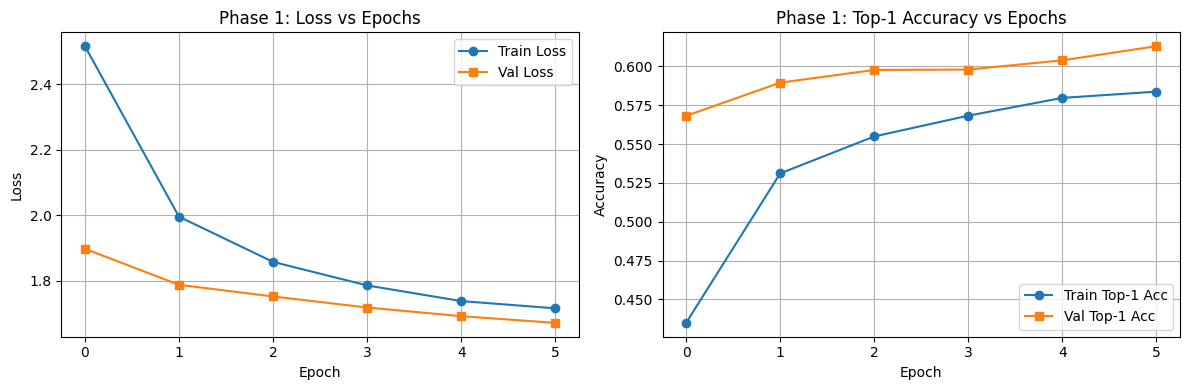


[SUMMARY] Best Phase 1 Validation Accuracy: 61.31%


In [6]:
# 1. Save weights locally on Colab runtime
model.save_weights("results/resnet50/phase1_feature_extractor.weights.h5")
print("[SUCCESS] Phase 1 weights saved locally.")

# 2. Mount your permanent Google Drive and copy the weights there
import shutil
from google.colab import drive

print("[INFO] Mounting Google Drive for permanent weight backup...")
drive.mount('/content/drive')

GDRIVE_DIR = "/content/drive/MyDrive/food101_checkpoints"
os.makedirs(GDRIVE_DIR, exist_ok=True)
shutil.copy("results/resnet50/phase1_feature_extractor.weights.h5", GDRIVE_DIR)
print(f"[SUCCESS] Weights permanently backed up to Google Drive: {GDRIVE_DIR}/phase1_feature_extractor.weights.h5")

# 3. Plot and save Phase 1 Training & Validation Metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_phase1.history['loss'], label='Train Loss', marker='o')
plt.plot(history_phase1.history['val_loss'], label='Val Loss', marker='s')
plt.title('Phase 1: Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_phase1.history['accuracy'], label='Train Top-1 Acc', marker='o')
plt.plot(history_phase1.history['val_accuracy'], label='Val Top-1 Acc', marker='s')
plt.title('Phase 1: Top-1 Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("results/resnet50/phase1_training_curves.png", dpi=300)
plt.show()

# Print best validation performance
best_val_acc = max(history_phase1.history['val_accuracy'])
print(f"\n[SUMMARY] Best Phase 1 Validation Accuracy: {best_val_acc * 100:.2f}%")


In [ ]:
# Cell 6: Phase 2 Fine-Tuning (Unfreezing Stage 5 Residual Blocks)
from src.models.resnet50 import unfreeze_resnet50_for_finetuning, compile_resnet50_model

unfrozen_count = unfreeze_resnet50_for_finetuning(model, base_model, fine_tune_from_layer="conv5_block1_out")
print(f"[INFO] Unfrozen {unfrozen_count} layers in ResNet50 backbone for fine-tuning.")

# Recompile with lower learning rate (1e-5) to protect pretrained representations
compile_resnet50_model(model, learning_rate=1e-5)
model.summary()

In [ ]:
# Cell 7: Phase 2 Training (Fine-Tuning Loop)
callbacks_phase2 = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    CSVLogger("results/resnet50/history_phase2.csv")
]

TOTAL_EPOCHS = 20
print(f"[INFO] Starting Phase 2 fine-tuning up to total epoch {TOTAL_EPOCHS}...")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=len(history_phase1.history["loss"]),
    callbacks=callbacks_phase2
)

In [ ]:
# Cell 8: Save Standardized 7 Evaluation Artifacts into results/resnet50/
print("[INFO] Model training complete. Proceed to standardized artifact generation.")
# Evaluated strictly on val_ds during development. Test set evaluated once final weights locked.